In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,transaction_id,customer_id,product_category,product_subcategory,quantity,unit_price,total_amount,placement_score
0,TXN_000001,CUST_0058,Dairy,Cheese,4,6.93,27.72,73.1
1,TXN_000001,CUST_0058,Meat,Chicken,1,5.41,5.41,37.6
2,TXN_000001,CUST_0058,Snacks,Crackers,3,3.80,11.40,74.4
3,TXN_000001,CUST_0058,Personal_Care,Toothpaste,1,2.91,2.91,40.8
4,TXN_000002,CUST_0045,Personal_Care,Soap,1,1.87,1.87,71.9


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1500
Columns: 8


In [6]:
print(df.columns.tolist())

['transaction_id', 'customer_id', 'product_category', 'product_subcategory', 'quantity', 'unit_price', 'total_amount', 'placement_score']


In [7]:
print("Unique transactions:", df["transaction_id"].nunique())
print("Unique customers:", df["customer_id"].nunique())

Unique transactions: 308
Unique customers: 196


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       1500 non-null   str    
 1   customer_id          1500 non-null   str    
 2   product_category     1500 non-null   str    
 3   product_subcategory  1500 non-null   str    
 4   quantity             1500 non-null   int64  
 5   unit_price           1500 non-null   float64
 6   total_amount         1500 non-null   float64
 7   placement_score      1500 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 93.9 KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
print("Categories:", df["product_category"].nunique())
print("Subcategories:", df["product_subcategory"].nunique())
category_counts = df["product_category"].value_counts()

category_counts

Categories: 11
Subcategories: 49


product_category
Produce          193
Dairy            175
Beverages        164
Meat             157
Pantry           150
Bakery           150
Snacks           134
Household        128
Personal_Care    126
Frozen           113
Unknown           10
Name: count, dtype: int64

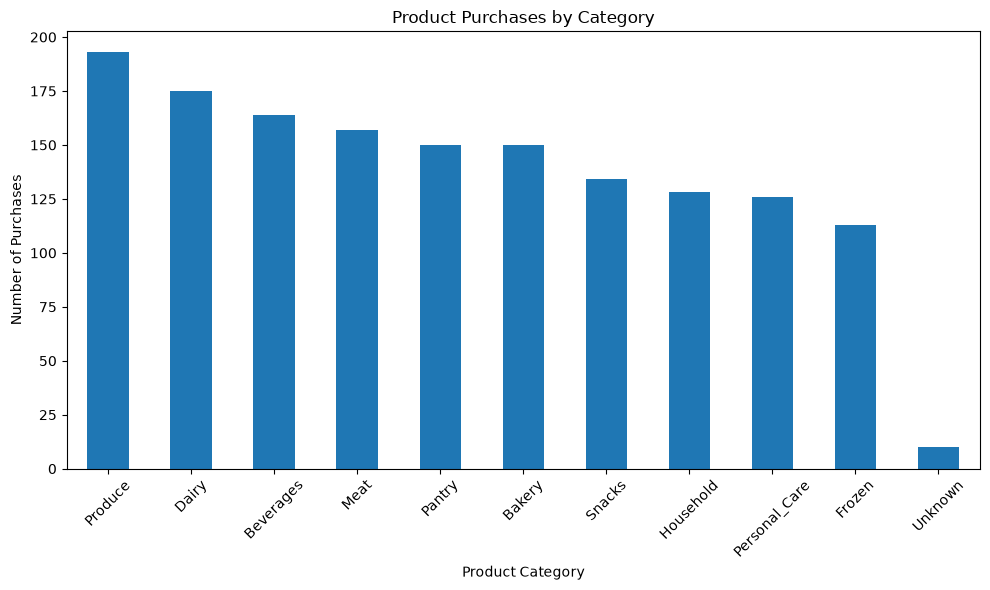

In [12]:
plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Product Purchases by Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
subcategory_counts = df["product_subcategory"].value_counts()

subcategory_counts.head(30)

product_subcategory
Cream                55
Coffee               49
Soap                 41
Pasta                41
Bagels               41
Shampoo              40
Beef                 39
Onions               38
Lettuce              38
Muffins              38
Frozen_Vegetables    38
Canned_Goods         36
Cookies              36
Toilet_Paper         35
Chips                35
Yogurt               33
Tomatoes             33
Juice                33
Ice_Cream            33
Crackers             32
Fish                 32
Soda                 32
Cleaning_Supplies    32
Bananas              31
Detergent            31
Deli_Meat            31
Apples               30
Paper_Towels         30
Butter               30
Bread                30
Name: count, dtype: int64

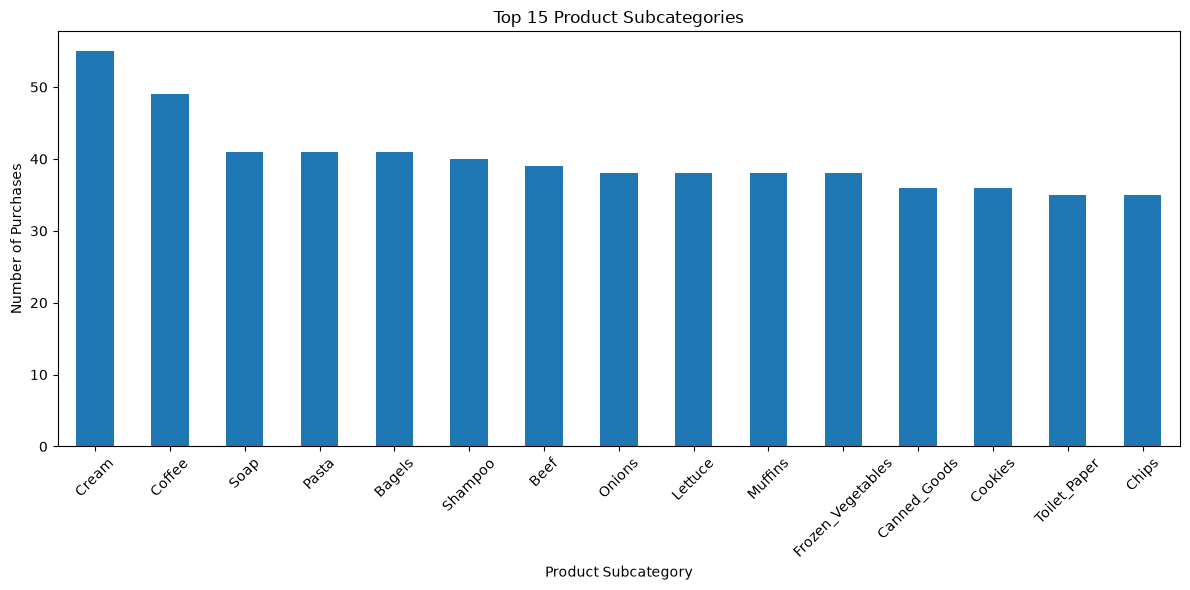

In [15]:
plt.figure(figsize=(12, 6))

subcategory_counts.head(15).plot(kind="bar")

plt.title("Top 15 Product Subcategories")
plt.xlabel("Product Subcategory")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
basket_size = df.groupby("transaction_id").size()

basket_size.head()

transaction_id
TXN_000001    4
TXN_000002    5
TXN_000003    6
TXN_000004    4
TXN_000005    6
dtype: int64

In [17]:
basket_size.describe()

count    308.00000
mean       4.87013
std        1.89531
min        2.00000
25%        3.00000
50%        5.00000
75%        6.00000
max       10.00000
dtype: float64

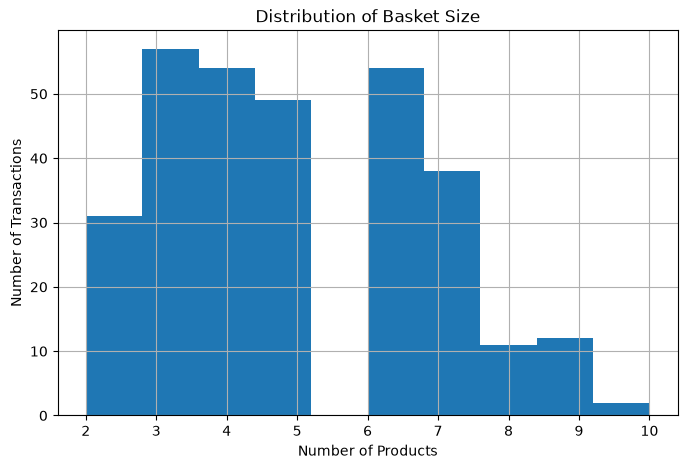

In [18]:
plt.figure(figsize=(8, 5))

basket_size.hist(bins=10)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Products")
plt.ylabel("Number of Transactions")

plt.show()

In [19]:
df["total_amount"].describe()

count    1500.00000
mean        9.42822
std         9.27873
min         0.92000
25%         3.64000
50%         6.36000
75%        11.56500
max        82.30000
Name: total_amount, dtype: float64

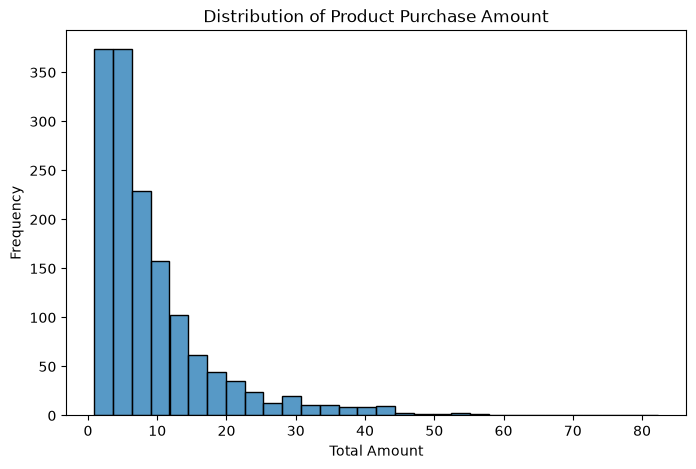

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df["total_amount"], bins=30)

plt.title("Distribution of Product Purchase Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

In [21]:
basket_value = df.groupby("transaction_id")["total_amount"].sum()

basket_value.describe()

count    308.000000
mean      45.916656
std       27.827941
min        2.870000
25%       26.562500
50%       41.450000
75%       58.275000
max      156.500000
Name: total_amount, dtype: float64

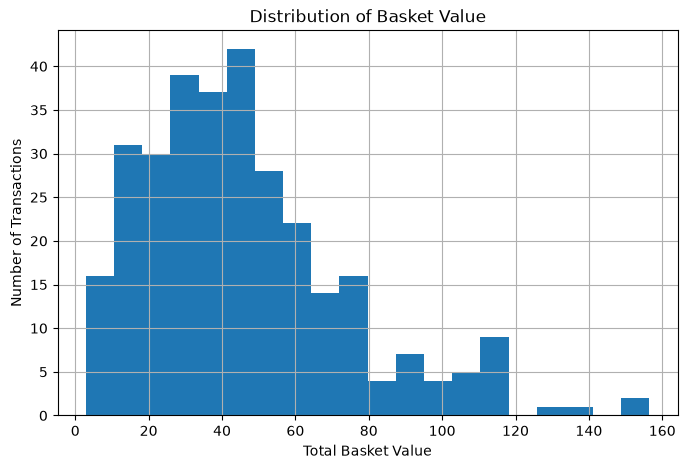

In [22]:
plt.figure(figsize=(8, 5))

basket_value.hist(bins=20)

plt.title("Distribution of Basket Value")
plt.xlabel("Total Basket Value")
plt.ylabel("Number of Transactions")

plt.show()

In [23]:
df["placement_score"].describe()

count    1500.000000
mean       79.137600
std        18.508843
min        23.400000
25%        65.975000
50%        82.950000
75%        96.000000
max       100.000000
Name: placement_score, dtype: float64

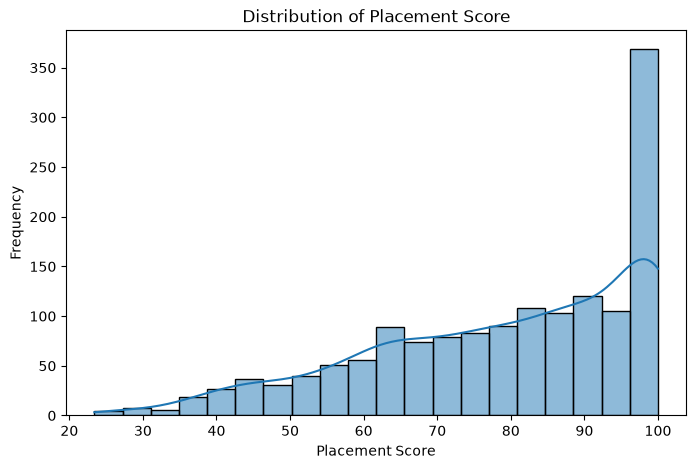

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(df["placement_score"], bins=20, kde=True)

plt.title("Distribution of Placement Score")
plt.xlabel("Placement Score")
plt.ylabel("Frequency")

plt.show()

In [25]:
df.sort_values(
    "placement_score",
    ascending=False
)[[
    "product_category",
    "product_subcategory",
    "quantity",
    "unit_price",
    "total_amount",
    "placement_score"
]].head(20)

,product_category,product_subcategory,quantity,unit_price,total_amount,placement_score
1497,Dairy,Yogurt,4,1.41,5.64,100.0
11,Produce,Onions,2,1.47,2.94,100.0
13,Meat,Beef,4,8.88,35.52,100.0
1496,Dairy,Cream,3,3.88,11.64,100.0
1010,Beverages,Soda,2,1.82,3.64,100.0
1011,Produce,Lettuce,3,3.00,9.00,100.0
1012,Pantry,Canned_Goods,1,2.79,2.79,100.0
1013,Pantry,Pasta,1,2.77,2.77,100.0
330,Dairy,Yogurt,3,2.30,6.90,100.0
357,Meat,Fish,3,16.89,50.67,100.0


In [26]:
df.sort_values(
    "placement_score",
    ascending=True
)[[
    "product_category",
    "product_subcategory",
    "quantity",
    "unit_price",
    "total_amount",
    "placement_score"
]].head(20)

,product_category,product_subcategory,quantity,unit_price,total_amount,placement_score
941,Meat,Chicken,1,5.13,5.13,23.4
1412,Meat,Chicken,1,5.39,5.39,23.8
1305,Pantry,Pasta,3,1.79,5.37,23.9
1333,Meat,Deli_Meat,1,4.44,4.44,25.7
1120,Personal_Care,Shampoo,1,4.85,4.85,26.4
1187,Beverages,Soda,1,2.50,2.50,27.3
1210,Produce,Apples,1,1.70,1.70,27.7
782,Dairy,Yogurt,1,2.16,2.16,27.7
249,Dairy,Cheese,1,4.73,4.73,28.4
1185,Snacks,Candy,1,1.78,1.78,28.8


In [27]:
df[
    [
        "quantity",
        "unit_price",
        "total_amount",
        "placement_score"
    ]
].corr()

,quantity,unit_price,total_amount,placement_score
quantity,1.000000,-0.028640,0.567154,0.179224
unit_price,-0.028640,1.000000,0.696300,0.104178
total_amount,0.567154,0.696300,1.000000,0.187085
placement_score,0.179224,0.104178,0.187085,1.000000


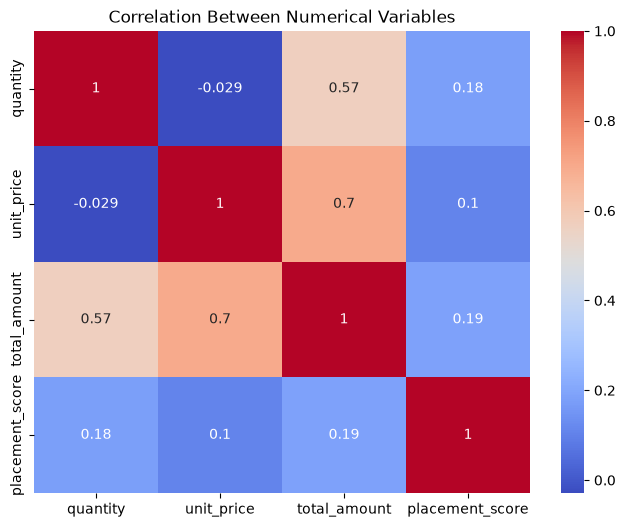

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[
        [
            "quantity",
            "unit_price",
            "total_amount",
            "placement_score"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [29]:
df["basket_size"] = df["transaction_id"].map(basket_size)

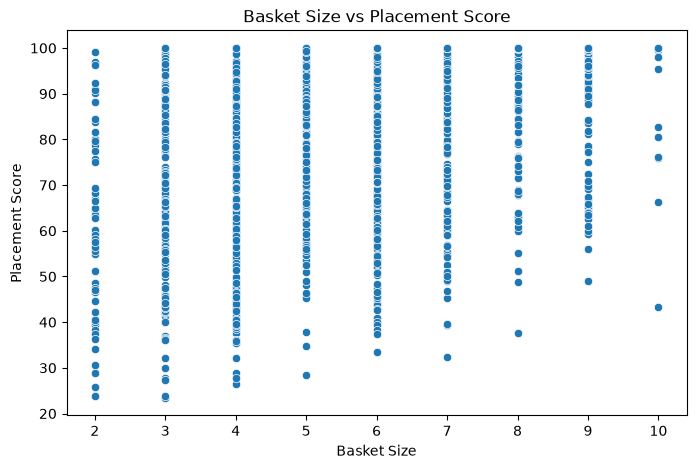

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="basket_size",
    y="placement_score"
)

plt.title("Basket Size vs Placement Score")
plt.xlabel("Basket Size")
plt.ylabel("Placement Score")

plt.show()

In [31]:
df["basket_size"].corr(df["placement_score"])

np.float64(0.3963582318075938)

In [32]:
category_score = (
    df.groupby("product_category")["placement_score"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

category_score

,mean,median,count
product_category,,,
Unknown,89.400000,96.40,10
Dairy,84.697143,88.10,175
Bakery,81.384000,86.90,150
Pantry,79.922667,83.25,150
Produce,79.787047,82.30,193
Household,79.714844,82.95,128
Beverages,78.842683,82.15,164
Snacks,78.828358,84.55,134
Meat,78.643312,83.10,157


In [33]:
## Market Basket Analysis

In [34]:
basket = (
    df.groupby("transaction_id")["product_subcategory"]
    .apply(list)
)

basket.head()

transaction_id
TXN_000001              [Cheese, Chicken, Crackers, Toothpaste]
TXN_000002        [Soap, Shampoo, Toothpaste, Crackers, Cheese]
TXN_000003        [Soap, Shampoo, Onions, Pasta, Beef, Cereals]
TXN_000004                      [Apples, Lettuce, Yogurt, Soap]
TXN_000005    [Cereals, Milk, Toilet_Paper, Spices, Paper_To...
Name: product_subcategory, dtype: object

In [35]:
from mlxtend.preprocessing import TransactionEncoder

In [38]:
te = TransactionEncoder()

basket_encoded = te.fit(basket).transform(basket)
basket_df = pd.DataFrame(
    basket_encoded,
    columns=te.columns_
)
basket_df.head()

,Apples,Bagels,Bananas,Beef,Beer,Bread,Butter,Cakes,Candy,Canned_Goods,...,Shampoo,Soap,Soda,Spices,Tea,Toilet_Paper,Tomatoes,Toothpaste,Water,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,False,False
2,False,False,False,True,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False


In [39]:
from mlxtend.frequent_patterns import apriori

In [40]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,
    use_colnames=True
)

In [41]:
frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets
17,0.178571,frozenset({Cream})
14,0.159091,frozenset({Coffee})
1,0.133117,frozenset({Bagels})
38,0.133117,frozenset({Soap})
33,0.133117,frozenset({Pasta})
58,0.129870,"frozenset({Coffee, Cream})"
37,0.129870,frozenset({Shampoo})
3,0.126623,frozenset({Beef})
29,0.123377,frozenset({Muffins})
27,0.123377,frozenset({Lettuce})


In [42]:
from mlxtend.frequent_patterns import association_rules

In [43]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

In [44]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Coffee}),frozenset({Bagels}),0.159091,0.133117,0.077922,0.489796,3.679443,1.0,0.056744,1.699091,0.865991,0.363636,0.411450,0.537581
1,frozenset({Bagels}),frozenset({Coffee}),0.133117,0.159091,0.077922,0.585366,3.679443,1.0,0.056744,2.028075,0.840044,0.363636,0.506922,0.537581
2,frozenset({Bagels}),frozenset({Cream}),0.133117,0.178571,0.113636,0.853659,4.780488,1.0,0.089865,5.613095,0.912253,0.573770,0.821845,0.745011
3,frozenset({Cream}),frozenset({Bagels}),0.178571,0.133117,0.113636,0.636364,4.780488,1.0,0.089865,2.383929,0.962733,0.573770,0.580524,0.745011
4,frozenset({Bananas}),frozenset({Yogurt}),0.100649,0.107143,0.077922,0.774194,7.225806,1.0,0.067138,3.954082,0.958032,0.600000,0.747097,0.750733


In [45]:
rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    "lift",
    ascending=False
).head(20)

,antecedents,consequents,support,confidence,lift
56,"frozenset({Juice, Ice_Cream})",frozenset({Cookies}),0.061688,1.000000,8.555556
57,frozenset({Cookies}),"frozenset({Juice, Ice_Cream})",0.061688,0.527778,8.555556
58,frozenset({Ice_Cream}),"frozenset({Cookies, Juice})",0.061688,0.575758,8.444444
55,"frozenset({Cookies, Juice})",frozenset({Ice_Cream}),0.061688,0.904762,8.444444
16,frozenset({Rice}),frozenset({Chicken}),0.071429,0.785714,8.344828
17,frozenset({Chicken}),frozenset({Rice}),0.071429,0.758621,8.344828
8,frozenset({Butter}),frozenset({Bread}),0.077922,0.800000,8.213333
9,frozenset({Bread}),frozenset({Butter}),0.077922,0.800000,8.213333
15,frozenset({Cheese}),frozenset({Crackers}),0.077922,0.827586,7.965517
14,frozenset({Crackers}),frozenset({Cheese}),0.077922,0.750000,7.965517


In [46]:
pair_rules = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
].copy()

In [47]:
pair_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    "lift",
    ascending=False
).head(20)

,antecedents,consequents,support,confidence,lift
16,frozenset({Rice}),frozenset({Chicken}),0.071429,0.785714,8.344828
17,frozenset({Chicken}),frozenset({Rice}),0.071429,0.758621,8.344828
9,frozenset({Bread}),frozenset({Butter}),0.077922,0.800000,8.213333
8,frozenset({Butter}),frozenset({Bread}),0.077922,0.800000,8.213333
15,frozenset({Cheese}),frozenset({Crackers}),0.077922,0.827586,7.965517
14,frozenset({Crackers}),frozenset({Cheese}),0.077922,0.750000,7.965517
12,frozenset({Cereals}),frozenset({Milk}),0.064935,0.689655,7.586207
13,frozenset({Milk}),frozenset({Cereals}),0.064935,0.714286,7.586207
20,frozenset({Detergent}),frozenset({Cleaning_Supplies}),0.077922,0.774194,7.451613
21,frozenset({Cleaning_Supplies}),frozenset({Detergent}),0.077922,0.750000,7.451613


In [48]:
association_features = {}

for _, row in pair_rules.iterrows():
    for product in row["antecedents"]:
        association_features.setdefault(product, []).append({
            "partner": list(row["consequents"])[0],
            "lift": row["lift"],
            "confidence": row["confidence"],
            "support": row["support"]
        })

    for product in row["consequents"]:
        association_features.setdefault(product, []).append({
            "partner": list(row["antecedents"])[0],
            "lift": row["lift"],
            "confidence": row["confidence"],
            "support": row["support"]
        })

In [49]:
association_features["Rice"]

[{'partner': 'Chicken',
  'lift': 8.344827586206897,
  'confidence': 0.7857142857142857,
  'support': 0.07142857142857142},
 {'partner': 'Chicken',
  'lift': 8.344827586206895,
  'confidence': 0.7586206896551724,
  'support': 0.07142857142857142}]